# **AlTar 2 - a toy model with epistemic uncertainties**

# **Step 2 - run AlTar**

This notebook follows the `step 1` notebook, in which the input files for **AlTar** have been prepared, in the directory `test1`:
- `static.gf.h5`, the Green's functions for a homogeneous half space
- `static.data.h5`, the synthetic data, calculated for a heterogeneous medium
- `static.Cd.h5`, the data covariance $\mathbf{C}_\mathrm{d}$
- `static.Cx.h5`, the misfit covariance $\mathbf{C}_\mathrm{\chi} = \mathbf{C}_\mathrm{d} + \mathbf{C}_\mathrm{p}$, with $\mathbf{C}_\mathrm{p}$ calculated from the initial model
- `static.kernel.h5`, `static.Cmu.h5` and `static.initialModel.h5`, the sensitivity kernels, the covariance of the shear moduli and the initial model, to update $\mathbf{C}_\mathrm{p}$ during the sampling

The assumed Green's functions do not correspond to the medium the data were calculated in; we want to see how accounting for this epistemic uncertainty changes the inferred slip. In this example, we will:
1. Configure three inversions, with the static model `altar.models.seismic.static`:
    - `slip_cd`: with $\mathbf{C}_\mathrm{d}$ only, ignoring the epistemic uncertainties;
    - `slip_cx`: with the fixed $\mathbf{C}_\mathrm{\chi}$;
    - `slip_cp`: with $\mathbf{C}_\mathrm{p}$ updated from the mean model during the sampling.
2. Run **AlTar**
3. Analyze the results

### 1. The configuration files

Each inversion has its own configuration file, for `slipmodel`, the **AlTar** application for slip models; each saves its samples to `results/<name>`. The one with the updated $\mathbf{C}_\mathrm{p}$, [slip_cp.pfg](slip_cp.pfg), is:

In [1]:
print(open('slip_cp.pfg').read())

;
; (c) 2013-present parasim inc
; (c) 2010-present california institute of technology
; all rights reserved
;

; the Cp toy model: C_p updated from the mean model during the sampling
slipmodel:
    ; the static model, d = G θ
    model = altar.models.seismic.static
    model:
        ; the directory with the input files from step 1
        case = test1
        ; the green's functions, (observations, parameters), for a homogeneous half space
        green = static.gf.h5

        ; the observed data
        dataobs:
            observations = 300
            data_file = static.data.h5
            cd_file = static.Cd.h5

        ; update C_p from the posterior mean model, from β = 0.01 on
        cp = altar.models.cp.adaptive
        cp:
            start = 0.01
            ; use the initial model until β = 0.01, then the posterior mean
            initial_model = static.initialModel.h5
            initial_until = 0.01
        ; the covariance of the shear moduli, and the sensitivity ker

With `model.cp = altar.models.cp.adaptive`, **AlTar** calculates $\mathbf{C}_\mathrm{p} = \mathbf{K}_\mathrm{p} \mathbf{C}_\mu \mathbf{K}_\mathrm{p}^T$, with $\mathbf{K}_\mathrm{p}[:, i] = \mathbf{K}_i \boldsymbol\theta$, from the initial model until $\beta$ = `cp.initial_until`, then from the mean of the samples at each $\beta$ step, and samples with the misfit covariance $\mathbf{C}_\mathrm{d} + \mathbf{C}_\mathrm{p}$.

[slip_cd.pfg](slip_cd.pfg) and [slip_cx.pfg](slip_cx.pfg) are the same, without the `cp` settings, and with `dataobs.cd_file` set to `static.Cd.h5` and `static.Cx.h5` respectively.

### 2. Run **AlTar**

We run `slipmodel` from the shell, once for each configuration; each run prints its progress at each $\beta$ step, of which only the first step is kept below. (A python process can only hold one **AlTar** application, so we can't run the three of them from within this notebook, as in the tutorial *An introduction to AlTar: the linear model*.)

In [2]:
!slipmodel --config=slip_cd.pfg

journal (altar):
 -- time: 2026-09-29T10:51:53.220542
journal (altar):
 -- iteration: 0, beta: 0, scaling: 0.1
journal (altar):
 -- stats(accepted/invalid/rejected): (0, 0, 0)
journal (altar):
 -- step
 --   β: 0
 --   θ_sampling: (1024 samples) x (20 parameters)
 --   parameters (mean, sd):
 --    (5.8502979150572205, 6.690604695300755)
 --    (5.7711320341373575, 6.327780982943661)
 --    (5.643020062058933, 6.717526444971459)
 --    (5.761929338851324, 6.827569698659266)
 --    (6.019065519729077, 6.528019713051984)
 --    (5.531654451807429, 6.128927054410354)
 --    (5.907567175310863, 6.85836638374275)
 --    (5.653764558906985, 6.42794004305443)
 --    (6.107940770586732, 6.985483615778745)
 --    (5.9168283767498515, 6.731469514272387)
 --    (6.034563895133451, 7.018968644492071)
 --    (5.659692750458615, 6.359938803252187)
 --    (5.796477712402364, 6.590409592122976)
 --    (5.87499482594015, 6.823333548259837)
 --    (6.163861339559528, 7.21229954765296)
 --    (5.82579416

In [3]:
!slipmodel --config=slip_cx.pfg

journal (altar):
 -- time: 2026-09-29T10:53:10.272025
journal (altar):
 -- iteration: 0, beta: 0, scaling: 0.1
journal (altar):
 -- stats(accepted/invalid/rejected): (0, 0, 0)
journal (altar):
 -- step
 --   β: 0
 --   θ_sampling: (1024 samples) x (20 parameters)
 --   parameters (mean, sd):
 --    (5.8502979150572205, 6.690604695300755)
 --    (5.7711320341373575, 6.327780982943661)
 --    (5.643020062058933, 6.717526444971459)
 --    (5.761929338851324, 6.827569698659266)
 --    (6.019065519729077, 6.528019713051984)
 --    (5.531654451807429, 6.128927054410354)
 --    (5.907567175310863, 6.85836638374275)
 --    (5.653764558906985, 6.42794004305443)
 --    (6.107940770586732, 6.985483615778745)
 --    (5.9168283767498515, 6.731469514272387)
 --    (6.034563895133451, 7.018968644492071)
 --    (5.659692750458615, 6.359938803252187)
 --    (5.796477712402364, 6.590409592122976)
 --    (5.87499482594015, 6.823333548259837)
 --    (6.163861339559528, 7.21229954765296)
 --    (5.82579416

In [4]:
!slipmodel --config=slip_cp.pfg

journal (altar):
 -- time: 2026-09-29T10:53:55.473836
journal (altar):
 -- iteration: 0, beta: 0, scaling: 0.1
journal (altar):
 -- stats(accepted/invalid/rejected): (0, 0, 0)
journal (altar):
 -- step
 --   β: 0
 --   θ_sampling: (1024 samples) x (20 parameters)
 --   parameters (mean, sd):
 --    (5.8502979150572205, 6.690604695300755)
 --    (5.7711320341373575, 6.327780982943661)
 --    (5.643020062058933, 6.717526444971459)
 --    (5.761929338851324, 6.827569698659266)
 --    (6.019065519729077, 6.528019713051984)
 --    (5.531654451807429, 6.128927054410354)
 --    (5.907567175310863, 6.85836638374275)
 --    (5.653764558906985, 6.42794004305443)
 --    (6.107940770586732, 6.985483615778745)
 --    (5.9168283767498515, 6.731469514272387)
 --    (6.034563895133451, 7.018968644492071)
 --    (5.659692750458615, 6.359938803252187)
 --    (5.796477712402364, 6.590409592122976)
 --    (5.87499482594015, 6.823333548259837)
 --    (6.163861339559528, 7.21229954765296)
 --    (5.82579416

The samples of the posterior are in `results/<name>/step_final.h5`:

In [5]:
import numpy as np
import h5py

def samples(name):
    """
    The samples of the posterior of the run {name}, (samples, parameters)
    """
    with h5py.File(f'results/{name}/step_final.h5', 'r') as h5:
        return h5['ParameterSets/strikeslip_sampling'][:]

theta_cd = samples('slip_cd')
theta_cx = samples('slip_cx')
theta_cp = samples('slip_cp')

### 3. Analyze the results

#### 3.1 The inferred slip

The mean and standard deviation of the slip of each subfault, against the target slip of 10 m:

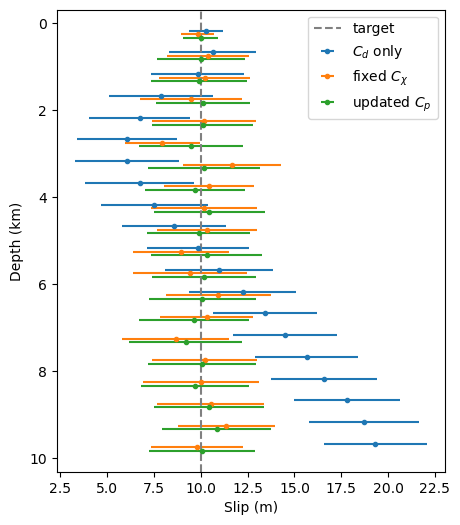

    $C_d$ only: mean slip  11.47 m, mean sd  2.66 m
fixed $C_\chi$: mean slip  10.04 m, mean sd  2.55 m
 updated $C_p$: mean slip  10.02 m, mean sd  2.71 m


In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

## the depth of the center of each subfault, in km
width, ndip = 10., 20
depth = (np.arange(ndip) + 0.5) * width / ndip

runs = {'$C_d$ only': theta_cd, r'fixed $C_\chi$': theta_cx, 'updated $C_p$': theta_cp}

fig, ax = plt.subplots(figsize=(5, 6))
for offset, (label, theta) in zip((-0.08, 0, 0.08), runs.items()):
    ax.errorbar(theta.mean(axis=0), depth + offset, xerr=theta.std(axis=0), fmt='o', ms=3, label=label)
ax.axvline(x=10., color='gray', ls='--', label='target')
ax.invert_yaxis()
ax.set_xlabel('Slip (m)')
ax.set_ylabel('Depth (km)')
ax.legend()
plt.show()

for label, theta in runs.items():
    print(f'{label:>14}: mean slip {theta.mean():6.2f} m, mean sd {theta.std(axis=0).mean():5.2f} m')

#### 3.2 The fit of the predictions to the observations

The predictions of the mean models, with the homogeneous Green's functions, against the data, for the $\mathbf{x}_3$ component:

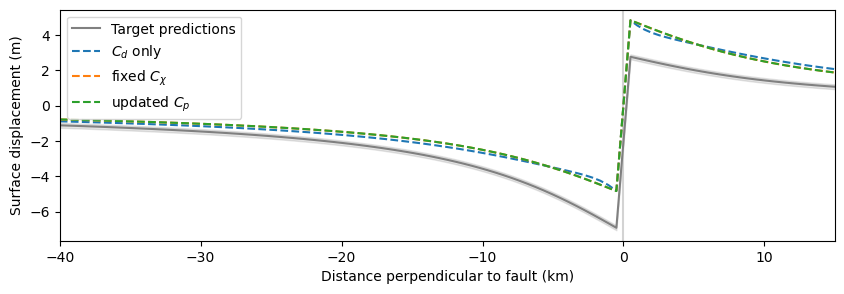

In [7]:
import h5py

with h5py.File('test1/static.gf.h5', 'r') as h5:
    G = h5['GFs'][:]
with h5py.File('test1/static.data.h5', 'r') as h5:
    data = h5['data'][:]
with h5py.File('test1/static.Cd.h5', 'r') as h5:
    Cd = h5['data errors'][:]
with h5py.File('test1/static.Cx.h5', 'r') as h5:
    Cx = h5['misfit covariance'][:]
data_sd = np.sqrt(np.diag(Cd))

## the data points, as in step 1, and the x3 component, the second third of the observations
x = np.concatenate((np.linspace(-40000, -500, 70), np.linspace(500, 15000, 30)))
x3 = slice(100, 200)

fig = plt.figure(figsize=(10, 3))
plt.axvline(x=0, color='lightgray')
plt.fill_between(x/1000, data[x3] - data_sd[x3], data[x3] + data_sd[x3], color='gray', alpha=0.2)
plt.plot(x/1000, data[x3], color='gray', label='Target predictions')
for label, theta in runs.items():
    plt.plot(x/1000, (G @ theta.mean(axis=0))[x3], '--', label=label)
plt.xlim([-40, 15])
plt.xlabel('Distance perpendicular to fault (km)')
plt.ylabel('Surface displacement (m)')
plt.legend()
plt.show()

And the misfit of each mean model, $\chi^2 = \mathbf{r}^T \mathbf{C}^{-1} \mathbf{r} / N$ with the residuals $\mathbf{r} = \mathbf{G} \bar{\boldsymbol\theta} - \mathbf{d}$, for $\mathbf{C} = \mathbf{C}_\mathrm{d}$ and for $\mathbf{C} = \mathbf{C}_\mathrm{\chi}$:

In [8]:
for label, theta in runs.items():
    r = G @ theta.mean(axis=0) - data
    chi2_d = r @ np.linalg.solve(Cd, r) / len(r)
    chi2_x = r @ np.linalg.solve(Cx, r) / len(r)
    print(f'{label:>14}: chi2 with Cd {chi2_d:8.2f}, with Cx {chi2_x:6.2f}')

    $C_d$ only: chi2 with Cd    19.74, with Cx   0.48
fixed $C_\chi$: chi2 with Cd    20.44, with Cx   0.07
 updated $C_p$: chi2 with Cd    20.45, with Cx   0.07


#### 3.3 Discussion

Ignoring the epistemic uncertainties, the inversion with $\mathbf{C}_\mathrm{d}$ only is biased. The homogeneous Green's functions under-predict the displacements on the compliant West side of the fault and over-predict them on the stiff East side, and no slip model fits both sides: none of the predictions above does. Since the network covers the West side better, the inversion with $\mathbf{C}_\mathrm{d}$ only trades one side against the other with a distorted slip distribution, too little slip at mid-depths and too much at depth, outside its standard deviations for many subfaults, for hardly any gain in the fit: its $\chi^2$ with $\mathbf{C}_\mathrm{d}$, about 20, is barely lower than that of the other two.

With $\mathbf{C}_\mathrm{p}$, fixed from the initial model or updated from the mean model, the inversion recovers the target slip within its uncertainties: $\mathbf{C}_\mathrm{\chi}$ tells the sampler that a misfit along the direction of the modelling error is expected, and the residuals are well within it ($\chi^2$ with $\mathbf{C}_\mathrm{\chi}$ is below 1, since the synthetic data have no noise). The fixed and the updated $\mathbf{C}_\mathrm{p}$ agree here because the initial model, a uniform slip of 5 m, has the shape of the target slip: in this toy model, the shape of the slip model sets the direction of $\mathbf{C}_\mathrm{p}$, and its magnitude only the amplitude. For an initial model whose shape differs from the solution, updating $\mathbf{C}_\mathrm{p}$ during the sampling matters.

In all three runs, the standard deviations of the deep subfaults stay close to the 3 m of the prior: the surface data hardly constrain the slip at depth, whatever the covariance.
